In [2]:
import torch
import torchvision
from torchvision import datasets, transforms

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.54MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 133kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.52MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.8MB/s]


In [3]:
print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 60000
Testing samples: 10000


In [4]:
image, label = train_dataset[0]
print("Image: ", image)
print("Label: ", label)

Image:  <PIL.Image.Image image mode=L size=28x28 at 0x7B9444A5AD50>
Label:  9


In [5]:
print(type(image))
print(label)

<class 'PIL.Image.Image'>
9


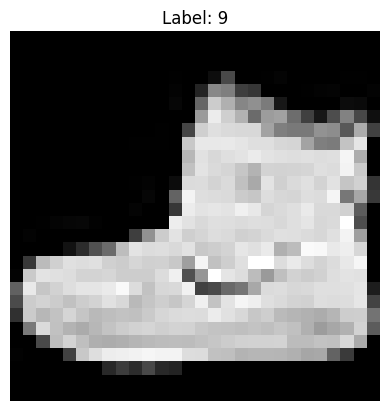

In [6]:
import matplotlib.pyplot as plt

image, label = train_dataset[0]

plt.imshow(image, cmap='gray')
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

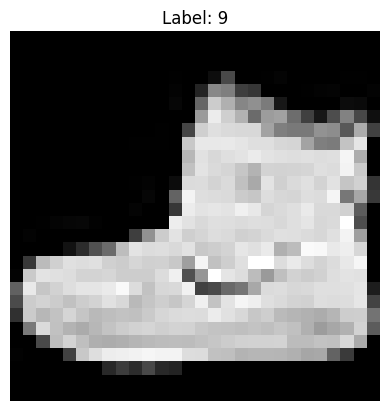

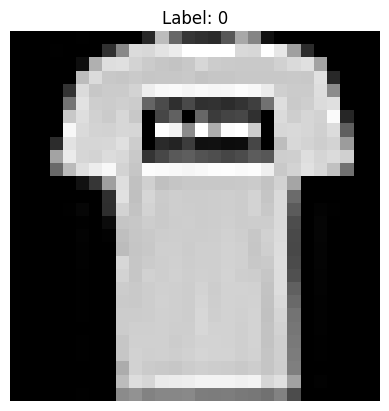

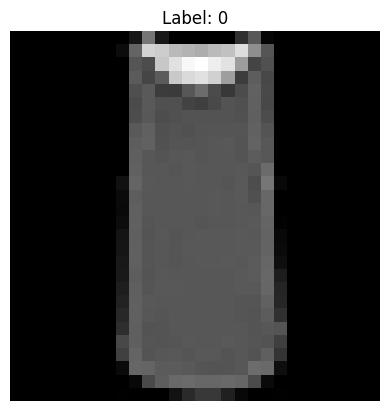

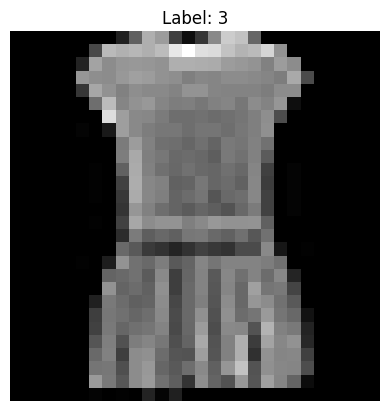

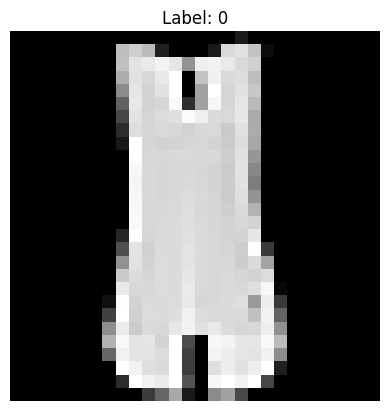

In [7]:
for i in range(5):
  image, label = train_dataset[i]

  plt.figure()
  plt.imshow(image, cmap='gray')
  plt.title(f"Label: {label}")
  plt.axis("off")
  plt.show()

In [8]:
class_name = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

In [9]:
image, label = train_dataset[0]

print("Label number: ", label)
print("Class: ", class_name[label])

Label number:  9
Class:  Ankle boot


In [10]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [11]:
from torch.nn.modules import transformer
train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)
test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [12]:
image, label = train_dataset[0]

print(type(image))
print(image.shape)
print(label)

<class 'torch.Tensor'>
torch.Size([1, 28, 28])
9


In [13]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [14]:
images, label = next(iter(train_loader))

print("Image shape: ", images.shape)
print("Labels shape: ", label.shape)

Image shape:  torch.Size([64, 1, 28, 28])
Labels shape:  torch.Size([64])


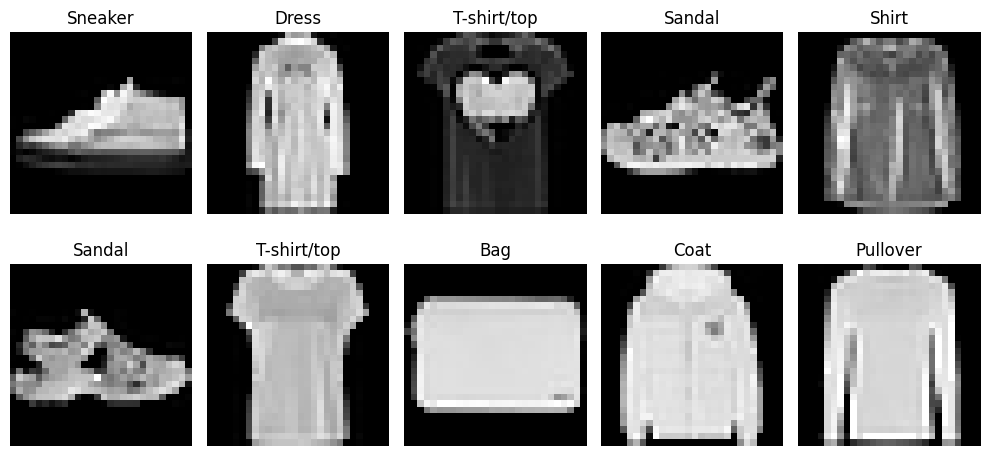

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap="gray")
    ax.set_title(class_name[label[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [16]:
# Now we have to built Neural Network

import torch
import torch.nn as nn

class NeuralNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(784, 128)
    self.fc2 = nn.Linear(128, 64)
    self.fc3 = nn.Linear(64, 10)
    self.relu = nn.ReLU()

  def forward(self, x):
    # [Batch_size, 1, 28, 28]
    x = x.view(x.size(0), -1)

    # [batch_size, 784]
    x = self.fc1(x)
    x = self.relu(x)

    # [batch_size, 128]
    x = self.fc2(x)
    x = self.relu(x)

    # [batch_size, 64]
    x = self.fc3(x)

    # [batch_size, 10]
    return x

model = NeuralNetwork()
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(10):
  model.train()
  total_loss=0
  for images, labels in train_loader:
    optimizer.zero_grad()
    Prediction = model(images)
    loss = loss_function(Prediction, labels)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
  avg_loss = total_loss/len(train_loader)
  print(
        f"Epoch : {epoch}, Loss : {loss.item():.4f}"
    )

Epoch : 0, Loss : 0.4535
Epoch : 1, Loss : 0.2146
Epoch : 2, Loss : 0.1746
Epoch : 3, Loss : 0.3579
Epoch : 4, Loss : 0.1833
Epoch : 5, Loss : 0.2295
Epoch : 6, Loss : 0.3359
Epoch : 7, Loss : 0.5271
Epoch : 8, Loss : 0.2986
Epoch : 9, Loss : 0.1445


In [17]:
# Validation and Evaluation

from torch.utils.data import random_split, DataLoader

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_data, val_data = random_split(
    train_dataset,
    [train_size, val_size]
)
print("Training smaples: ", len(train_data))
print("Validation samples: ", len(val_data))
print("Test smaples: ", len(test_dataset))

Training smaples:  48000
Validation samples:  12000
Test smaples:  10000


In [18]:
from typing_extensions import dataclass_transform
train_loader = DataLoader(
    train_data,
    batch_size = 64,
    shuffle = True
)
val_loader = DataLoader(
    val_data,
    batch_size = 64,
    shuffle = False
)
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)


In [19]:
def validate_model(model, val_loader, loss_function):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            predictions = model(images)

            loss = loss_function(predictions, labels)

            total_loss += loss.item()

            _, predicted = torch.max(predictions, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    average_loss = total_loss / len(val_loader)

    accuracy = correct / total

    return average_loss, accuracy

In [20]:
import os
os.makedirs("models", exist_ok=True)

In [22]:
torch.save(
    model.state_dict(),
    "models/neuralnet_fashion_mnist.pth"
)

In [23]:
import os

print(os.listdir("models"))

['neuralnet_fashion_mnist.pth']


In [24]:
model.state_dict()

OrderedDict([('fc1.weight',
              tensor([[-0.0599, -0.0734,  0.0093,  ...,  0.2519,  0.2436,  0.0764],
                      [ 0.2216,  0.2076,  0.0689,  ..., -0.1027, -0.1803,  0.1233],
                      [ 0.2170,  0.2930,  0.3964,  ..., -0.2244,  0.0857,  0.3160],
                      ...,
                      [ 0.0878,  0.2009,  0.0634,  ..., -0.1945, -0.1507, -0.0142],
                      [-0.0844,  0.0328, -0.0419,  ..., -0.0783, -0.3077, -0.1799],
                      [-0.1520,  0.0959,  0.3051,  ..., -0.0282,  0.0068, -0.0623]])),
             ('fc1.bias',
              tensor([ 1.3195e-01,  3.2935e-01,  2.8172e-01,  2.8815e-01, -2.2429e-01,
                      -7.6770e-03,  4.3595e-01,  1.2817e-01,  2.9684e-01,  2.2523e-01,
                      -1.5041e-01,  1.7145e-01,  4.2700e-03, -4.4414e-01,  9.9358e-03,
                      -1.4249e-01,  2.8492e-01,  5.8058e-01,  3.2207e-01, -1.9226e-01,
                       1.1231e-01,  4.0541e-01, -7.2505e-02, -1.

In [25]:
loaded_model = NeuralNetwork()
loaded_model.load_state_dict(
    torch.load("models/neuralnet_fashion_mnist.pth")
)

<All keys matched successfully>

In [26]:
loaded_model.eval()

NeuralNetwork(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)

In [27]:
images, labels = next(iter(test_loader))

with torch.no_grad():
    predictions = loaded_model(images)

_, predicted = torch.max(predictions, 1)

print("Predicted:", predicted[:10].tolist())
print("Actual:   ", labels[:10].tolist())

Predicted: [9, 2, 1, 1, 6, 1, 4, 6, 5, 7]
Actual:    [9, 2, 1, 1, 6, 1, 4, 6, 5, 7]


In [29]:
model.state_dict()

OrderedDict([('fc1.weight',
              tensor([[-0.0599, -0.0734,  0.0093,  ...,  0.2519,  0.2436,  0.0764],
                      [ 0.2216,  0.2076,  0.0689,  ..., -0.1027, -0.1803,  0.1233],
                      [ 0.2170,  0.2930,  0.3964,  ..., -0.2244,  0.0857,  0.3160],
                      ...,
                      [ 0.0878,  0.2009,  0.0634,  ..., -0.1945, -0.1507, -0.0142],
                      [-0.0844,  0.0328, -0.0419,  ..., -0.0783, -0.3077, -0.1799],
                      [-0.1520,  0.0959,  0.3051,  ..., -0.0282,  0.0068, -0.0623]])),
             ('fc1.bias',
              tensor([ 1.3195e-01,  3.2935e-01,  2.8172e-01,  2.8815e-01, -2.2429e-01,
                      -7.6770e-03,  4.3595e-01,  1.2817e-01,  2.9684e-01,  2.2523e-01,
                      -1.5041e-01,  1.7145e-01,  4.2700e-03, -4.4414e-01,  9.9358e-03,
                      -1.4249e-01,  2.8492e-01,  5.8058e-01,  3.2207e-01, -1.9226e-01,
                       1.1231e-01,  4.0541e-01, -7.2505e-02, -1.

In [30]:
from google.colab import files

files.download(
    "models/neuralnet_fashion_mnist.pth"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>